In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

In [4]:
df = pd.read_csv('CC GENERAL.csv')
data = df.drop('CUST_ID', axis=1)

In [5]:
imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(data)

In [6]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_imputed)

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.1

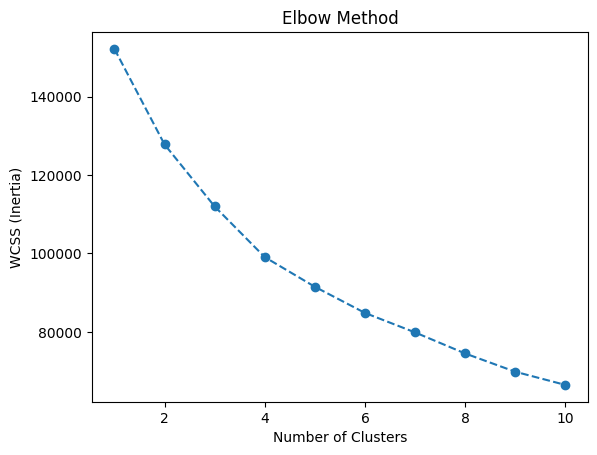

In [8]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [9]:
from sklearn.decomposition import PCA

In [10]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [12]:
loadings = pd.DataFrame(pca.components_.T, 
                        columns=['PC1', 'PC2'], 
                        index=data.columns)

print("Top contributors to PC1:")
print(loadings['PC1'].sort_values(ascending=False).head(3))

print("\nTop contributors to PC2:")
print(loadings['PC2'].sort_values(ascending=False).head(3))

Top contributors to PC1:
PURCHASES           0.411562
PURCHASES_TRX       0.390599
ONEOFF_PURCHASES    0.346334
Name: PC1, dtype: float64

Top contributors to PC2:
CASH_ADVANCE              0.439027
CASH_ADVANCE_FREQUENCY    0.434121
CASH_ADVANCE_TRX          0.419643
Name: PC2, dtype: float64


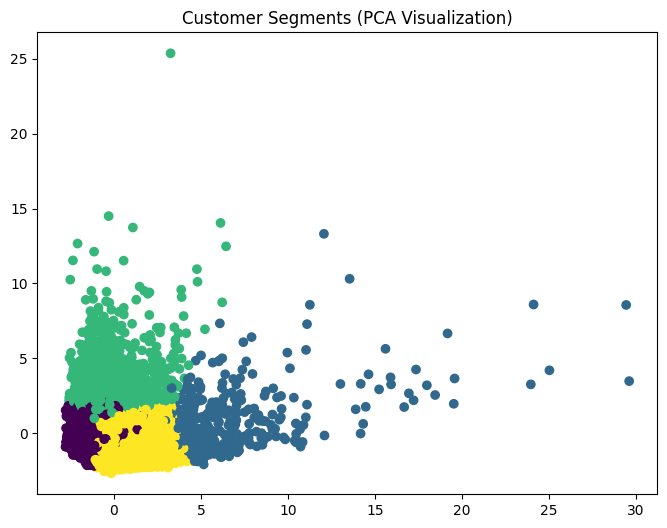

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.title('Customer Segments (PCA Visualization)')
plt.show()

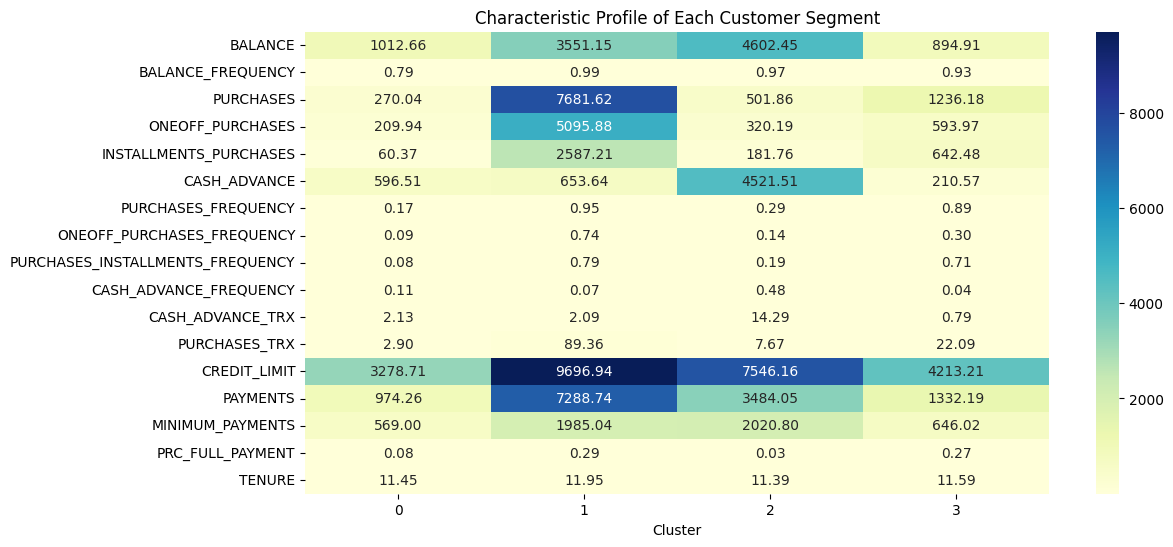

In [14]:
import seaborn as sns

df['Cluster'] = clusters

cluster_profile = df.drop('CUST_ID', axis=1).groupby('Cluster').mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Characteristic Profile of Each Customer Segment')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from scipy.stats import mode

true_labels = []
for i in range(len(df)):
    row = df.iloc[i]
    if row['PURCHASES'] > 500 and row['CREDIT_LIMIT'] > 5000 and row['PAYMENTS'] > 1500:
        true_labels.append(1)        
    elif row['CASH_ADVANCE'] > 1000 and row['CASH_ADVANCE_FREQUENCY'] > 0.3:
        true_labels.append(2)        
    elif row['PURCHASES_FREQUENCY'] > 0.5 or row['PURCHASES_INSTALLMENTS_FREQUENCY'] > 0.4:
        true_labels.append(3)        
    else:
        true_labels.append(0)       

true_labels = np.array(true_labels)
predicted_labels = np.array(clusters)

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=["Low-Activity", "High-Purchaser", "Cash-Advance", "Balanced-Spender"]
))

acc = accuracy_score(true_labels, predicted_labels)
print(f"Overall Accuracy: {acc*100:.2f}%")

                  precision    recall  f1-score   support

    Low-Activity       0.83      0.93      0.88      3530
  High-Purchaser       0.79      0.31      0.45      1041
    Cash-Advance       0.61      0.70      0.65      1055
Balanced-Spender       0.84      0.85      0.84      3324

        accuracy                           0.80      8950
       macro avg       0.77      0.70      0.70      8950
    weighted avg       0.80      0.80      0.79      8950

Overall Accuracy: 80.10%
